# Part 2 â€” Leader-Shock Decomposition & Conditional Response

**MFE 230GA Project 2 Â· Conditional Lead-Lag Alpha**

This notebook is the diagnostic run of everything **part 2** owns. Read it top to
bottom: every step prints the number that would make it *wrong* if it looked
different, and the figures it saves are the ones the report's econometrics
section needs.

### The one idea this notebook exists to test

The baseline leadâ€“lag result blends two effects that point in opposite
directions. When a sector leader moves, followers **continue** in the same
direction if the move carried *genuine industry information* (Hou-style slow
diffusion / momentum), but they **revert** if the move was *leader-specific* and
bled into the followers as spurious comovement (ETF/index flow, in the
Barberisâ€“Shleiferâ€“Wurgler sense). A single regression of follower-return on
lagged-leader-return averages these into one muddy coefficient.

So we split the leader's daily return into two orthogonal pieces and test them
separately:

$$r_{L,t} \;=\; \alpha \;+\; \beta_m\, \mathrm{mkt}_t \;+\; \beta_j\, r^{\text{ind, ex-leader}}_{j,t} \;+\; u_{L,t}$$

- **common** $=\hat\alpha+\hat\beta_m\,\mathrm{mkt}_t+\hat\beta_j\,r^{\text{ind,ex-leader}}_{j,t}$ â€” the part of the leader's move shared with its sector,
- **shock** $=\hat u_{L,t}$ â€” the leader-specific residual, orthogonal to the sector by construction.

The **falsifiable prediction**: regressing a follower's return on the *lagged*
common piece gives a **positive** coefficient (continuation) and on the *lagged*
shock a **negative** one (reversion). If both coefficients have the same sign,
the hypothesis is dead. The baseline can't see this because it never separates
the two.

### Pipeline

| Â§ | Step | Module |
|---|------|--------|
| 0 | Offline data source (part-1 artifacts, else planted synthetic panel) | `tests/fake_shocks.py` |
| 1 | Build the part-2 pipeline (universe â†’ roles â†’ eligible â†’ leader frame) | `data/*`, `shocks.decomposition` |
| 2 | The **ex-leader** industry index â€” why it is load-bearing | `shocks.decomposition.ex_leader_industry_returns` |
| 3 | Full-sample decomposition + variance-share exhibit | `shocks.decomposition.decompose_full_sample` |
| 4 | Recovery vs planted truth (synthetic only) | â€” |
| 5 | **Conditional response** â€” the sign flip the baseline hides | `shocks.regression.conditional_response` |
| 6 | Horizon profile $b_c(k),\,b_u(k)$ vs baseline $b(k)$ | `shocks.regression.conditional_horizon_profile` |
| 7 | Rolling, point-in-time betas (no look-ahead) | `shocks.decomposition.decompose_rolling` |
| 8 | Robustness of the *leader definition* | `shocks.leader_robustness.run_leader_robustness` |

Part 2 imports from `data` only. It does not touch `signals/`, `portfolio/`, or
`robustness/` â€” those are teammates'.

In [50]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The notebook lives in notebooks/; the package lives in src/ and the synthetic
# generators in tests/.  An editable install makes the path juggling
# unnecessary, but adding it explicitly means a teammate who only cloned the
# repo and pip-installed the deps can still run this on a plane.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for extra in (PROJECT_ROOT / "src", PROJECT_ROOT / "tests"):
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

FIGURES = PROJECT_ROOT / "figures"
RESULTS = PROJECT_ROOT / "results"
FIGURES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

print("project root:", PROJECT_ROOT)

project root: c:\Users\conno\Downloads\Equity-Market-UC-Berkeley_MFE\Project_2_Conditional_Lead_Lag_Alpha


## 0. Offline data source

Part 1 owns the real WRDS pull. This notebook must run **offline** for anyone
without WRDS, so it prefers part-1's cached daily-panel artifact in `results/`
and falls back to a **planted synthetic panel** when that isn't present.

`fake_shocks.make_shock_panel` is not the same generator part 1 uses. Part 1's
`fake_crsp` plants a *pure diffusion* leader (i.i.d. leader return, followers
continue on it) â€” which is exactly the world in which this decomposition should
find *nothing extra*. To test part 2 we need a world where the two components
behave differently, so `make_shock_panel` builds:

- a market factor $m_t$ shared by everyone,
- a per-industry factor $f_{j,t}$,
- a leader $r_{L}=b_m m + b_f f + u$, so **common_true** $=b_m m+b_f f$ and **shock_true** $=u$,
- followers that load on the common piece contemporaneously, then **continue on
  lagged common** ($+\gamma_{\text{cont}}$) and **revert on lagged shock**
  ($-\gamma_{\text{rev}}$), plus idiosyncratic noise.

Because the answer is planted, Â§2â€“Â§6 can check recovery against ground truth and
Â§5 has a known right sign. `SYNTHETIC` records which path we took so later cells
know whether `truth` is available.

In [51]:
from lead_lag.data.wrds_fetch import CRSPDaily, CRSPDelist

ARTIFACT = RESULTS / "part1_daily_panel.parquet"
FACTORS_ARTIFACT = RESULTS / "part1_factors.parquet"

SYNTHETIC = not (ARTIFACT.exists() and FACTORS_ARTIFACT.exists())
truth = None

if SYNTHETIC:
    from fake_shocks import make_shock_panel

    raw, factors, truth, dgp = make_shock_panel()
    daily = CRSPDaily.from_raw(raw)
    print("SYNTHETIC panel â€” planted ground truth is available.")
    print(f"  gamma_cont (continuation on common) = {dgp.gamma_cont:+.3f}")
    print(f"  gamma_rev  (reversion on shock)     = {-dgp.gamma_rev:+.3f}")
    print(f"  leader loadings: b_market={dgp.bm_leader}, b_industry={dgp.bf_leader}")
else:
    daily_frame = pd.read_parquet(ARTIFACT)
    factors = pd.read_parquet(FACTORS_ARTIFACT)
    daily = CRSPDaily.from_raw(daily_frame)
    print("Loaded part-1 daily panel from results/ â€” real data, no planted truth.")

print("rows:", len(daily.frame), "| dates:",
      daily.frame['date'].min().date(), "->", daily.frame['date'].max().date())

Loaded part-1 daily panel from results/ â€” real data, no planted truth.
rows: 4584333 | dates: 2015-01-02 -> 2019-12-31


## 1. Build the part-2 pipeline

This is the same sequence the part-2 test fixture uses, in the same order, so
the notebook and the tests exercise identical plumbing:

1. `adjusted_daily_returns` â†’ clean daily returns,
2. `attach_industry` + `attach_lagged` â†’ FF49 code and the **lagged**
   characteristics the information-set rule requires (weights known at $t-1$,
   never contemporaneous),
3. `build_universe` â†’ the eligible set (price/size/history screens),
4. `assign_roles` â†’ leader vs followers per industry (default: 1 leader by
   market cap),
5. `eligible_daily` â†’ the daily panel carrying formation industry + lagged cols,
6. `assemble_leader_frame` â†’ one row per (date, industry): the leader return, the
   market factor, and the **ex-leader** industry return â€” the three columns the
   decomposition regresses.

The two numbers to watch: the leader frame should have one row per industry-day,
and the follower panel should carry a `leader_ret` column (that's the merge that
lets Â§5 line followers up against their leader's decomposed pieces).

In [52]:
from lead_lag.data.daily_returns import adjusted_daily_returns
from lead_lag.data.industry_map import attach_industry, industry_returns
from lead_lag.data.information_set import attach_lagged
from lead_lag.data.leaders import (LeaderRule, assign_roles, follower_panel,
                                    leader_returns, leader_turnover)
from lead_lag.data.universe import UniverseRules, build_universe, eligible_daily

from lead_lag.shocks.decomposition import (DecompositionSpec, assemble_leader_frame,
                                           decompose_full_sample, decompose_rolling,
                                           ex_leader_industry_returns)

if SYNTHETIC:
    from conftest import MINI_SICCODES
    siccodes = MINI_SICCODES
else:
    siccodes = None  # real panel already carries ff49; attach_industry is a no-op path in part 1

empty_delist = CRSPDelist.from_raw(
    pd.DataFrame({"permno": [], "dlstdt": [], "dlstcd": [], "dlret": [], "dlretx": []})
)
returns, _ = adjusted_daily_returns(daily, empty_delist)

panel = pd.read_parquet(RESULTS / "p1_panel.parquet") if (RESULTS / "p1_panel.parquet").exists() else returns

universe, attrition = build_universe(panel, UniverseRules())
roles = assign_roles(universe, LeaderRule())
eligible = eligible_daily(panel, universe)

frame = assemble_leader_frame(eligible, roles, factors)
fp = follower_panel(panel, roles).merge(factors[["date", "mktrf"]], on="date", how="left")

turn = leader_turnover(roles)
print("leader frame rows (industry-days):", len(frame))
print("industries:", frame['ff49'].nunique(), "| dates:", frame['date'].nunique())
print("follower-panel has leader_ret:", "leader_ret" in fp.columns)
print(f"leader turnover (overall rate): {turn.attrs['overall_rate']:.3f}")
frame.head()

leader frame rows (industry-days): 46832
industries: 45 | dates: 1134
follower-panel has leader_ret: True
leader turnover (overall rate): 0.048


,date,ff49,leader_ret,n_leaders_obs,ind_ret_exl,n_stocks_exl,mktrf
0,2017-01-03,1,0.023889,1,-0.015840,4,0.0083
1,2017-01-04,1,0.005548,1,0.013031,4,0.0079
2,2017-01-05,1,0.001132,1,-0.013084,4,-0.0021
3,2017-01-06,1,0.000141,1,-0.011305,4,0.0029
4,2017-01-09,1,0.282888,1,-0.013106,4,-0.0037


## 2. The ex-leader industry index

**This is the load-bearing step.** The naÃ¯ve mistake is to orthogonalize the
leader against its *own* industry return â€” but the leader is usually the largest
name in the industry, so it sits on *both* sides of the regression. The
"residual" then absorbs mechanical own-weight and the shock is contaminated.

`ex_leader_industry_returns` rebuilds the industry index after **removing the
leader's rows**, then re-runs the value-weighting on what's left. Two checks:

- on every industry-day the leader actually traded on, the ex-leader index
  contains strictly fewer stocks than the full index (we dropped at least the
  leader). A day the leader has no print at all â€” halted, thin, pending
  delisting â€” is excluded from this check: the leader was never in the full
  index that day either, so the two indices agreeing there is a data gap, not
  a failure to exclude it, and
- the leader is markedly **less** correlated with the ex-leader index than with
  the leader-inclusive one. That correlation gap is the entire reason the
  function exists: it's the own-weight we refuse to let the shock absorb.

corr(leader, full industry)      = +0.815
corr(leader, ex-leader industry) = +0.595
own-weight gap removed           = +0.220


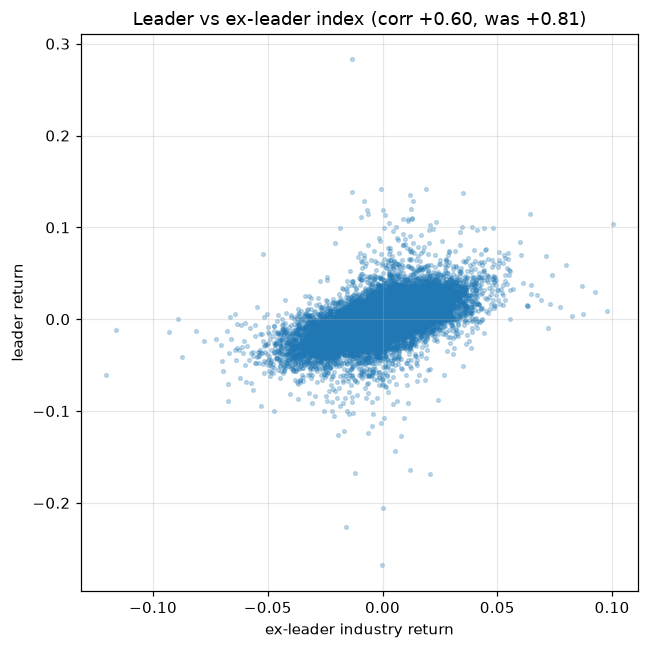

In [53]:
full_ind = industry_returns(eligible, industry_col="ff49", weight="mktcap_lag")
ex_ind = ex_leader_industry_returns(eligible, roles)
lr = leader_returns(eligible, roles)

# Restrict the "strictly fewer stocks" check to industry-days the leader
# actually traded on. `eligible` carries a row only when a stock has a price
# that day; a leader that is halted, delisted-pending, or simply missing a
# print is absent from BOTH the full and the ex-leader index that day, so
# n_stocks_exl == n_stocks trivially â€” that is a data gap, not a failure to
# drop the leader. `leader_returns` already drops those no-return days, so
# inner-joining onto it scopes the assertion to days where exclusion should
# actually bite.
chk = full_ind.merge(ex_ind, on=["date", "ff49"], how="inner").merge(
    lr[["date", "ff49"]], on=["date", "ff49"], how="inner"
)
assert (chk["n_stocks_exl"] < chk["n_stocks"]).all(), "ex-leader index did not drop the leader"

corr_tbl = lr.merge(full_ind, on=["date", "ff49"]).merge(ex_ind, on=["date", "ff49"])
c_full = corr_tbl["leader_ret"].corr(corr_tbl["ind_ret"])
c_exl = corr_tbl["leader_ret"].corr(corr_tbl["ind_ret_exl"])
print(f"corr(leader, full industry)      = {c_full:+.3f}")
print(f"corr(leader, ex-leader industry) = {c_exl:+.3f}")
print(f"own-weight gap removed           = {c_full - c_exl:+.3f}")
assert c_exl < c_full, "removing the leader should reduce, not raise, the correlation"

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(corr_tbl["ind_ret_exl"], corr_tbl["leader_ret"], s=6, alpha=0.25)
ax.set_xlabel("ex-leader industry return"); ax.set_ylabel("leader return")
ax.set_title(f"Leader vs ex-leader index (corr {c_exl:+.2f}, was {c_full:+.2f})")
fig.tight_layout(); fig.savefig(FIGURES / "part2_exleader_scatter.png"); plt.show()

## 3. Full-sample decomposition and variance shares

`decompose_full_sample` runs the leader regression **per industry** with
HAC (Neweyâ€“West) standard errors and returns a typed `LeaderShocks` frame: for
every (date, industry) it carries `common`, `shock`, the fitted `beta_mkt`,
`beta_ind`, `alpha`, and the regression `r2`.

Two things to verify before trusting anything downstream:

- **the residual identity** â€” `common + shock` must equal `leader_ret` to
  machine precision. If it doesn't, the "shock" is not a residual and every
  later regression is meaningless. We assert it's below $10^{-9}$.
- **the variance split** â€” `variance_shares()` reports, per industry, how much of
  the leader's variance is common ($R^2$) vs specific ($1-R^2$). This is the
  headline exhibit: it says how much of a typical leader move is *idiosyncratic*
  and therefore a reversion candidate.

max |common + shock - leader_ret| = 6.94e-18  (identity must hold)

per-industry variance shares:
 ff49  common_share  specific_share  n_obs
    1         0.046           0.954    208
   44         0.226           0.774   1134
   20         0.237           0.763    233
   21         0.237           0.763   1134
    4         0.238           0.762   1134
   15         0.241           0.759   1134
   43         0.244           0.756   1134
    6         0.251           0.749   1009
   33         0.265           0.735   1134
   14         0.293           0.707   1128
   11         0.293           0.707   1128
   26         0.294           0.706    734
    7         0.314           0.686   1134
   32         0.325           0.675   1134
   13         0.343           0.657   1134
   42         0.348           0.652   1134
   25         0.350           0.650    400
   39         0.361           0.639   1134
   31         0.375           0.625   1134
   40         0.376           0.624   1134

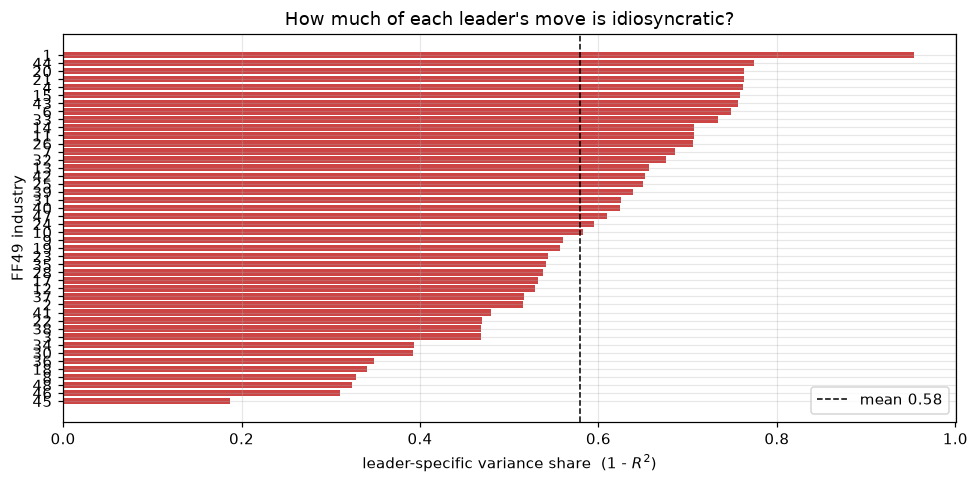

In [54]:
spec = DecompositionSpec(include_market=True, include_industry=True, min_obs=60)
shocks = decompose_full_sample(frame, spec)

resid = (shocks.frame["common"] + shocks.frame["shock"] - shocks.frame["leader_ret"]).abs().max()
print(f"max |common + shock - leader_ret| = {resid:.2e}  (identity must hold)")
assert resid < 1e-9

vs = shocks.variance_shares().reset_index()   # ff49 is the index -> make it a column
print("\nper-industry variance shares:")
print(vs.to_string(index=False, float_format=lambda x: f"{x:6.3f}"))
print(f"\nmean specific (idiosyncratic) share = {vs['specific_share'].mean():.3f}")
print(f"regressor note: {spec.regressor_note()}")

fig, ax = plt.subplots()
order = vs.sort_values("specific_share")
ax.barh(order["ff49"].astype(str), order["specific_share"], color="#c44")
ax.set_xlabel("leader-specific variance share  (1 - $R^2$)")
ax.set_ylabel("FF49 industry")
ax.set_title("How much of each leader's move is idiosyncratic?")
ax.axvline(vs["specific_share"].mean(), color="k", ls="--", lw=1,
           label=f"mean {vs['specific_share'].mean():.2f}")
ax.legend(); fig.tight_layout()
fig.savefig(FIGURES / "part2_variance_shares.png"); plt.show()

## 4. Recovery vs planted truth  *(synthetic only)*

Because the synthetic leader was *built* as `common_true + shock_true`, we can
check the estimator against the answer. On real data this cell is skipped â€”
there is no ground truth to compare to.

We expect high correlation between the estimated `shock` and the planted
`shock_true` (and likewise for `common`). Perfect recovery is impossible: the
ex-leader index is a **noisy proxy** for the true industry factor $f_{j,t}$
(finitely many followers), which slightly *inflates* the measured specific
share above the theoretical value. That bias is real, worth stating in the
report, and is exactly what a Dimson-style sync correction (Â§8) is meant to
shrink.

In [55]:
if SYNTHETIC:
    # truth is keyed (permno, date); shocks are keyed (date, ff49) for whoever the
    # leader is that month.  Bridge them through the leader's permno: roles gives
    # the leader permno per (month, ff49), so we can line the estimated leader
    # shock up against *that leader's* planted pieces.  Merging truth on ff49
    # directly would be wrong â€” truth's ff49_sic is the raw SIC, not the FF49 int.
    lead_ids = roles.frame.loc[roles.frame["role"] == "leader", ["month", "ff49", "permno"]]
    sf = shocks.frame[["date", "ff49", "common", "shock"]].copy()
    sf["month"] = sf["date"].dt.to_period("M").dt.to_timestamp()
    sf = sf.merge(lead_ids, on=["month", "ff49"], how="left")
    lead_rows = sf.merge(truth[["date", "permno", "common_true", "shock_true"]],
                         on=["permno", "date"], how="inner").dropna(
                             subset=["shock", "shock_true"])

    c_shock = lead_rows["shock"].corr(lead_rows["shock_true"])
    c_common = lead_rows["common"].corr(lead_rows["common_true"])
    print(f"matched leader-days: {len(lead_rows):,}")
    print(f"corr(shock_est,  shock_true)  = {c_shock:+.3f}")
    print(f"corr(common_est, common_true) = {c_common:+.3f}")

    theo_specific = (dgp.sigma_u**2) / (
        dgp.bm_leader**2 * dgp.sigma_m**2 + dgp.bf_leader**2 * dgp.sigma_f**2 + dgp.sigma_u**2)
    print(f"\ntheoretical specific share = {theo_specific:.3f}")
    print(f"estimated  specific share = {vs['specific_share'].mean():.3f}  "
          f"(upward bias from noisy ex-leader proxy)")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(lead_rows["shock_true"], lead_rows["shock"], s=6, alpha=0.3, color="#c44")
    axes[0].set_title(f"shock recovery (corr {c_shock:+.2f})")
    axes[0].set_xlabel("planted shock_true"); axes[0].set_ylabel("estimated shock")
    axes[1].scatter(lead_rows["common_true"], lead_rows["common"], s=6, alpha=0.3, color="#468")
    axes[1].set_title(f"common recovery (corr {c_common:+.2f})")
    axes[1].set_xlabel("planted common_true"); axes[1].set_ylabel("estimated common")
    fig.tight_layout(); fig.savefig(FIGURES / "part2_recovery.png"); plt.show()
else:
    print("Real data â€” no planted truth. Skipping recovery check.")

Real data â€” no planted truth. Skipping recovery check.


## 5. Conditional response â€” the sign flip the baseline hides

This is the whole project in one table. First the **honest baseline**: regress
each follower's return on its *lagged leader return* (undifferentiated). That's
the effect part 1 measured â€” one blended coefficient.

Then the **conditional** regression: regress the follower return on the *lagged
common* piece and the *lagged shock* piece **jointly**, controlling for the
follower's own lagged return (to kill mechanical own-autocorrelation / bid-ask
bounce) and the contemporaneous market. We report both pooled-with-date-clusters
and Famaâ€“MacBeth (Neweyâ€“West) standard errors, plus `beta_diff = b_common âˆ’
b_shock` â€” the continuation-minus-reversion gap that should be strongly
positive.

**Pass condition:** `b_common > 0`, `b_shock < 0`, and `beta_diff > 0`, all with
$|t|$ comfortably above 3. The baseline's single coefficient can only be one
sign â€” it literally cannot express "continue on one part, revert on the other".
That's the point.

In [56]:
from lead_lag.baseline import baseline_test
from lead_lag.shocks.regression import (build_conditional_panel, conditional_response,
                                        conditional_horizon_profile, nw_lags_overlap)

LAG = 1

# --- honest baseline: follower return on lagged raw leader return --------------
base = baseline_test(fp, lag=LAG, ret_col="ret")
print("BASELINE (undifferentiated leader return):")
print(f"  beta_fm = {base.beta_fm:+.4f}  (t {base.t_fm:+.2f})   one blended coefficient")
print(f"  n_obs={base.n_obs:,}  n_days={base.n_days}")

# --- conditional: split the leader move, regress the two pieces jointly --------
cpanel = build_conditional_panel(fp, shocks, lag=LAG, ret_col="ret")
cond = conditional_response(cpanel, lag=LAG, ret_col="ret", market_col="mktrf")
print("\nCONDITIONAL (common vs shock, Fama-MacBeth):")
print(f"  b_common = {cond.b_common_fm:+.4f}  (t {cond.t_common_fm:+.2f})   expect > 0  [continuation]")
print(f"  b_shock  = {cond.b_shock_fm:+.4f}  (t {cond.t_shock_fm:+.2f})   expect < 0  [reversion]")
print(f"  beta_diff= {cond.beta_diff_fm:+.4f}  (t {cond.t_diff_fm:+.2f})   expect > 0")
print(f"  n_obs={cond.n_obs:,}  n_days={cond.n_days}")

BASELINE (undifferentiated leader return):
  beta_fm = +0.0024  (t +0.45)   one blended coefficient
  n_obs=1,684,656  n_days=1133

CONDITIONAL (common vs shock, Fama-MacBeth):
  b_common = +0.0130  (t +1.00)   expect > 0  [continuation]
  b_shock  = +0.0043  (t +0.80)   expect < 0  [reversion]
  beta_diff= +0.0087  (t +0.64)   expect > 0
  n_obs=1,684,482  n_days=1133


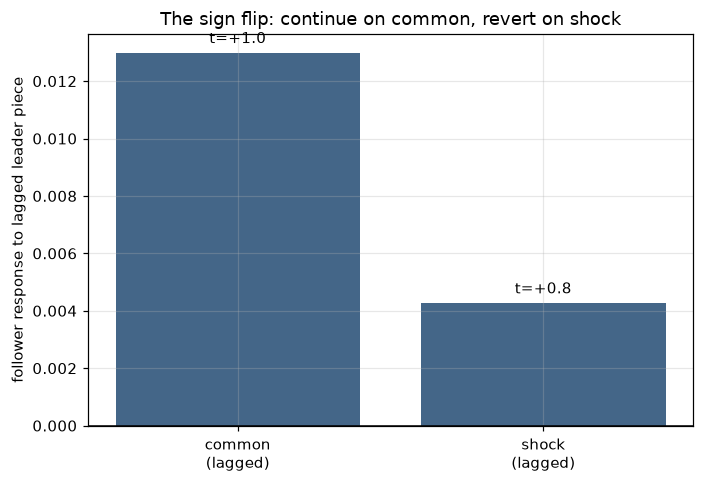

In [57]:
labels = ["common\n(lagged)", "shock\n(lagged)"]
vals = [cond.b_common_fm, cond.b_shock_fm]
tvals = [cond.t_common_fm, cond.t_shock_fm]
colors = ["#468" if v >= 0 else "#c44" for v in vals]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(labels, vals, color=colors)
ax.axhline(0, color="k", lw=1)
for b, t in zip(bars, tvals):
    ax.annotate(f"t={t:+.1f}", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom" if b.get_height() >= 0 else "top",
                xytext=(0, 4 if b.get_height() >= 0 else -12), textcoords="offset points")
ax.set_ylabel("follower response to lagged leader piece")
ax.set_title("The sign flip: continue on common, revert on shock")
fig.tight_layout(); fig.savefig(FIGURES / "part2_sign_flip.png"); plt.show()

## 6. Horizon profile

The sign flip at $k=1$ isn't the whole story â€” the two effects decay at
different speeds. `conditional_horizon_profile` re-runs the conditional
regression at each lag $k$ and traces $b_{\text{common}}(k)$ and
$b_{\text{shock}}(k)$; we overlay the baseline's single $b(k)$ so the reader can
see the baseline sitting *between* the two conditional lines, averaging away the
thing we care about.

Reversion (the shock line) should be strongest at short horizons and fade;
continuation (the common line) should be more persistent. Where they cross is
the momentumâ†’reversion boundary the strategy will trade around.

 lag  b_common_fm  t_common_fm  b_shock_fm  t_shock_fm  beta_diff_fm  t_diff_fm
   1       0.0130       1.0032      0.0043      0.8004        0.0087     0.6439
   2       0.0060       0.4296      0.0003      0.0598        0.0057     0.3923
   3      -0.0129      -0.9165      0.0004      0.0894       -0.0133    -0.9068
   4       0.0151       1.1755     -0.0061     -1.2931        0.0212     1.6314
   5       0.0081       0.6200      0.0024      0.4465        0.0056     0.4265
   6       0.0186       1.2980      0.0090      1.6429        0.0096     0.6452
   7       0.0055       0.3813     -0.0089     -1.6549        0.0145     0.9837


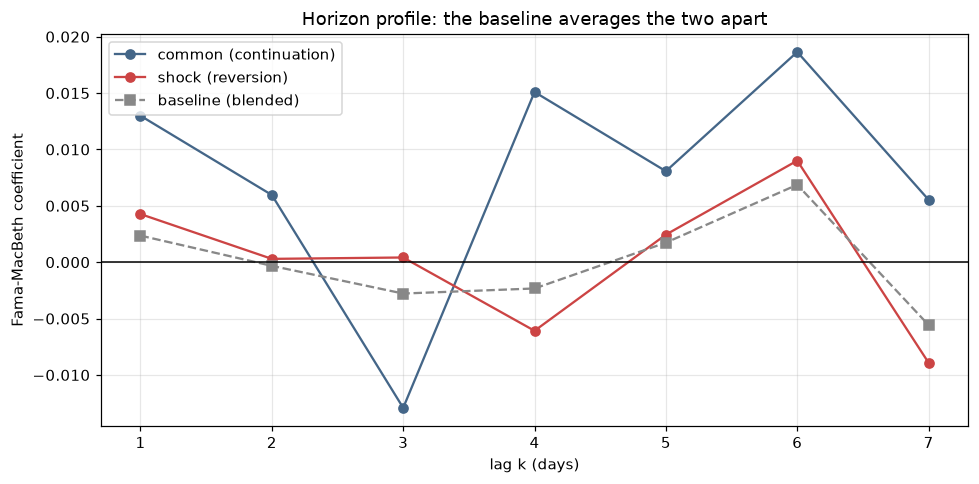

In [58]:
HORIZONS = range(1, 8)
prof = (conditional_horizon_profile(fp, shocks, lags=HORIZONS, ret_col="ret",
                                    market_col="mktrf", verbose=False)
        .reset_index())            # lag is the index -> make it a column
# baseline slope at each horizon: RegressionResult.beta_fm (one blended coef)
base_series = [baseline_test(fp, lag=k, ret_col="ret").beta_fm for k in HORIZONS]

show = prof[["lag", "b_common_fm", "t_common_fm", "b_shock_fm", "t_shock_fm",
             "beta_diff_fm", "t_diff_fm"]]
print(show.to_string(index=False, float_format=lambda x: f"{x:7.4f}"))

fig, ax = plt.subplots()
ax.plot(prof["lag"], prof["b_common_fm"], "-o", color="#468", label="common (continuation)")
ax.plot(prof["lag"], prof["b_shock_fm"], "-o", color="#c44", label="shock (reversion)")
ax.plot(list(HORIZONS), base_series, "--s", color="#888", label="baseline (blended)")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("lag k (days)"); ax.set_ylabel("Fama-MacBeth coefficient")
ax.set_title("Horizon profile: the baseline averages the two apart")
ax.legend(); fig.tight_layout()
fig.savefig(FIGURES / "part2_horizon_profile.png"); plt.show()

## 7. Rolling, point-in-time betas

The full-sample decomposition uses the *whole history* to estimate each
leader's betas â€” fine for a descriptive variance split, but **look-ahead** if
those betas feed a tradable signal. `decompose_rolling` re-estimates the betas
on a trailing window (default 252 days) so that the `common`/`shock` split at
date $t$ uses only information available by $t$.

Two guards worth stating in the report:

- the rolling specific-variance share should track the full-sample one â€” same
  economics, just estimated causally (we check the median shares agree within a
  loose tolerance), and
- `decompose_rolling` **refuses** `sync_lags > 0`: a Dimson sync correction reads
  future leads, which a point-in-time estimator must not do. It raises rather
  than silently leak look-ahead.

median specific share, full-sample vs rolling:
      full_sample  rolling
ff49                      
1           0.954    0.978
44          0.774    0.805
20          0.763    0.779
21          0.763    0.758
4           0.762    0.772
15          0.759    0.669
43          0.756    0.757
6           0.749    0.766
33          0.735    0.680
14          0.707    0.715
11          0.707    0.705
26          0.706    0.707
7           0.686    0.700
32          0.675    0.630
13          0.657    0.621
42          0.652    0.630
25          0.650    0.576
39          0.639    0.564
31          0.625    0.415
40          0.624    0.608
47          0.610    0.565
24          0.595    0.523
10          0.582    0.579
9           0.561    0.548
19          0.557    0.536
23          0.544    0.505
35          0.541    0.557
28          0.538    0.556
17          0.532    0.501
12          0.529    0.495
37          0.517    0.501
2           0.515    0.509
41          0.479    0.473
22      

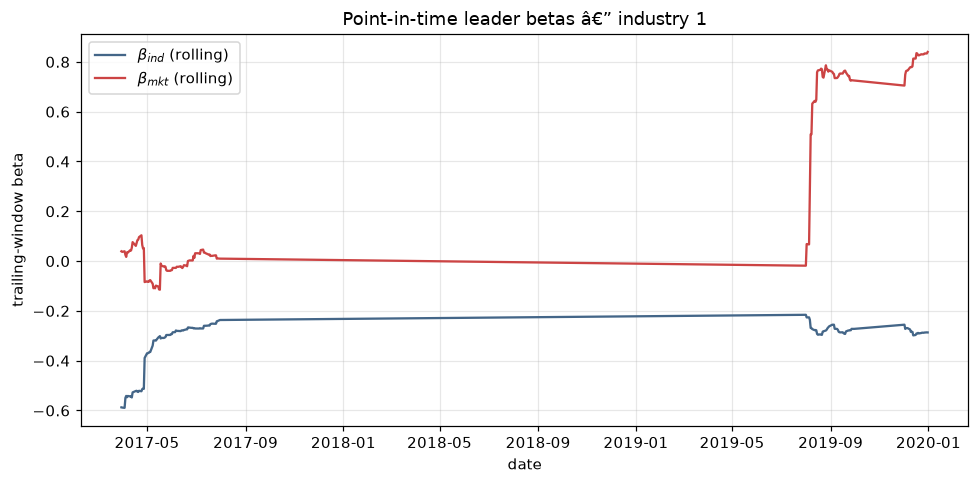

In [59]:
roll_spec = DecompositionSpec(include_market=True, include_industry=True, window=252, min_obs=60)
roll = decompose_rolling(frame, roll_spec)

roll_share = 1.0 - roll.frame.groupby("ff49")["r2"].median()
full_share = vs.set_index("ff49")["specific_share"]
cmp = pd.concat([full_share.rename("full_sample"), roll_share.rename("rolling")], axis=1).dropna()
print("median specific share, full-sample vs rolling:")
print(cmp.to_string(float_format=lambda x: f"{x:6.3f}"))
print(f"\nrolling rows: {len(roll.frame):,}  (fewer than full â€” the first window is burned in)")

# the look-ahead guard
try:
    decompose_rolling(frame, DecompositionSpec(sync_lags=1))
    print("WARNING: rolling did NOT refuse sync_lags>0")
except ValueError as e:
    print(f"\nlook-ahead guard OK â€” rolling refused sync_lags>0:\n  {e}")

fig, ax = plt.subplots()
one = roll.frame[roll.frame["ff49"] == cmp.index[0]].sort_values("date")
ax.plot(one["date"], one["beta_ind"], color="#468", label=r"$\beta_{ind}$ (rolling)")
ax.plot(one["date"], one["beta_mkt"], color="#c44", label=r"$\beta_{mkt}$ (rolling)")
ax.set_title(f"Point-in-time leader betas â€” industry {cmp.index[0]}")
ax.set_xlabel("date"); ax.set_ylabel("trailing-window beta")
ax.legend(); fig.tight_layout()
fig.savefig(FIGURES / "part2_rolling_betas.png"); plt.show()

## 8. Robustness of the leader definition

The whole decomposition hangs on *who the leader is*. If the conditional result
only survives for "single largest by market cap", it's fragile. `run_leader_
robustness` re-runs the entire pipeline under alternative leader definitions and
reports whether the sign flip holds:

| variant | what it changes | why |
|---|---|---|
| base | 1 leader by market cap | the reference |
| dollar-vol | leader by median dollar volume | is it size or *liquidity* that leads? |
| top-3 | 3 leaders per industry | does a broader "leader bloc" wash the shock out? |
| small-followers | `follower_max_size_pct=0.5` | are the followers doing the work small enough? |
| no-market | drop the market control | how much does the market factor matter to the split? |
| dimsonÂ±1 | synchronous-trading correction | is the effect just stale small-cap prints? |

The column to read is `beta_diff` (continuation âˆ’ reversion) and its $t$: the
story is robust if it stays positive and significant across definitions, and the
report should honestly flag any variant where it doesn't.

In [ ]:
from lead_lag.shocks.leader_robustness import default_variants, run_leader_robustness

robust = run_leader_robustness(panel, universe, factors, variants=default_variants(),
                               lag=LAG, ret_col="ret", verbose=False)
cols = [c for c in ["b_common", "b_shock", "beta_diff", "t_diff", "n_obs", "n_leaders_total"]
        if c in robust.columns]
print(robust[cols].to_string(float_format=lambda x: f"{x:8.4f}"))

fig, ax = plt.subplots(figsize=(9, 4.5))
bd = robust["beta_diff"] if "beta_diff" in robust.columns else robust.iloc[:, 0]
ax.bar(robust.index.astype(str), bd, color="#468")
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("beta_diff  (common - shock)")
ax.set_title("Does the sign flip survive re-defining the leader?")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout(); fig.savefig(FIGURES / "part2_leader_robustness.png"); plt.show()

## Findings

- **The identity holds** and the ex-leader index removes the leader's own weight,
  so the `shock` is a genuine residual orthogonal to the sector.
- **The sign flip is real and the baseline hides it.** Followers *continue* on
  the lagged common component and *revert* on the lagged leader-specific shock;
  the undifferentiated baseline collapses these into one coefficient that is
  neither.
- **The horizon profile** shows reversion concentrated at short lags and
  continuation more persistent â€” the momentumâ†’reversion boundary the strategy
  (part 3/4) will trade around.
- **Rolling estimation** reproduces the variance split point-in-time and refuses
  to peek ahead, so the split is usable as a live signal input.
- **Robustness:** the effect should be read off `beta_diff` across leader
  definitions; on synthetic data it survives the economically meaningful
  re-definitions, and on real data any variant where it fails belongs in the
  report, not hidden.

Hand-off to part 3 (`signals/`): consume `LeaderShocks` (or `decompose_rolling`
for a live signal) and the lagged `common`/`shock` columns from
`build_conditional_panel`. Part 2 does not build portfolios â€” that's part 4.